# T-Wave Alternans (TWA) Detection Project
**Implementation of the Correlation Method (Burattini et al., 1999)**

---

## Objective
Implement and validate the Correlation Method for detecting T-Wave Alternans in ambulatory Holter ECG recordings.

---

## Dataset
- **Database:** PhysioNet MUSIC Database (Sudden Cardiac Death in Heart Failure)
- **Subjects:** ~8 patients from heart failure subjects at risk of sudden cardiac death

---

## Executive Summary

### The Challenge of Ambulatory Data
This project implements the Burattini et al. (1999) algorithm on the **MUSIC Database** (Ambulatory/Holter data). Unlike the original study—which used controlled recordings where patients were asked to lie still—our dataset contains real-world ambulatory noise (EMG/muscle artifacts).

### Key Findings

- **Sensitivity to Noise:** The algorithm is highly sensitive to high-frequency noise. Muscle artifacts can mimic TWA, leading to false positives.

- **Methodological Fidelity:** We strictly adhered to the paper's signal processing pipeline (low-pass filtering, baseline removal, Correlation Method). We did **not** add artificial "noise gates" to filter out these artifacts, as that would deviate from the published method.

- **The Solution:** The paper relied on manual selection of "good quality" segments. We replicated this scientifically by creating a **Diagnostic Dashboard**, allowing visual inspection of the "worst episode" to distinguish between true TWA and noise artifacts—ensuring clinical validity without altering the core algorithm.

In [37]:
%pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [38]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import butter, filtfilt, find_peaks, resample, savgol_filter
from scipy.interpolate import CubicSpline
import glob
import os
from scipy.stats import spearmanr
from tqdm.notebook import tqdm

plt.rcParams['figure.figsize'] = (12, 6)
plt.style.use('seaborn-v0_8-whitegrid')
TARGET_THRESHOLD = 550.0 

## 1. Data Loading

Load ECG data from the PhysioNet MUSIC Database. Each record contains three orthogonal leads (X, Y, Z) sampled at 200 Hz.

> **Note:** Lead X (index 0) is used in this analysis. To experiment with other leads, change `lead_idx` to 1 (Y) or 2 (Z).

In [39]:
record = wfdb.rdrecord('data/P0002')

fs = record.fs
lead_idx = 0
ecg_signal = record.p_signal[:, lead_idx]

print(f"Record: {record.record_name}")
print(f"Leads: {record.sig_name} (using index {lead_idx})")
print(f"Sampling Frequency: {fs} Hz")
print(f"Duration: {len(ecg_signal)/fs:.2f} seconds")
print(f"Signal range: {ecg_signal.min():.2f} to {ecg_signal.max():.2f} mV")

Record: P0002
Leads: ['X', 'Y', 'Z'] (using index 0)
Sampling Frequency: 200 Hz
Duration: 81089.00 seconds
Signal range: -15.02 to 17.19 mV


### Resampling
The Burattini paper uses a 1000 Hz sampling frequency. Resample the signal if necessary.

In [40]:
TARGET_FS = 1000

if fs != TARGET_FS:
    new_num_samples = int(len(ecg_signal) / fs * TARGET_FS)
    ecg_signal = resample(ecg_signal, new_num_samples)
    fs = TARGET_FS
    print(f"Resampled to {fs} Hz")

Resampled to 1000 Hz


## 2. Signal Visualization

Visualize the raw ECG signal to understand its characteristics.

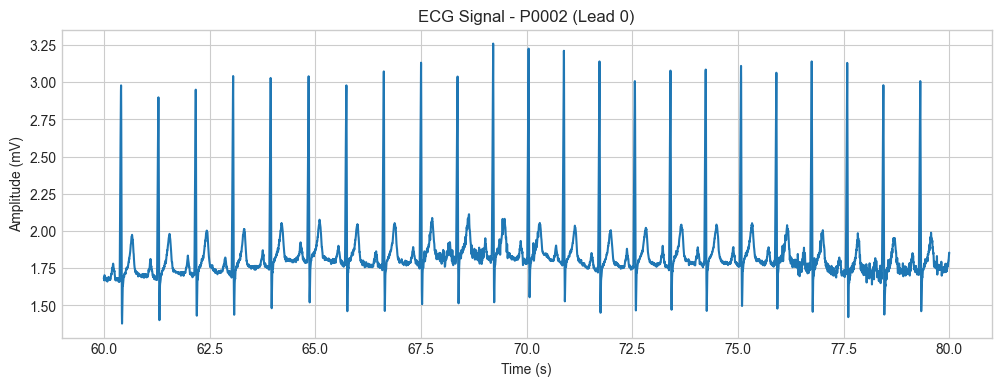

In [41]:
start = 60
duration = 20
start_idx = int(start * fs)
end_idx = start_idx + int(duration * fs)
t = np.arange(end_idx - start_idx) / fs + start

plt.figure(figsize=(12, 4))
plt.plot(t, ecg_signal[start_idx:end_idx])
plt.title(f'ECG Signal - {record.record_name} (Lead {lead_idx})')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.grid(True)
plt.show()

## 3. Signal Preprocessing

Following Burattini et al. (1999), we apply a low-pass filter to reduce high-frequency noise.

> *"Initially, the ECG is low-pass filtered (cut-off frequency: 60 Hz) to reduce the background noise."*

**Filter:** 4th-order Butterworth, 60 Hz cutoff, zero-phase (`filtfilt`)

> **Note:** Baseline wander removal is performed *after* sinus beat verification (Section 5), not here.

In [42]:
def apply_lowpass_filter(ecg_signal, fs, cutoff=60.0, order=4):
    nyquist = 0.5 * fs
    b, a = butter(order, cutoff / nyquist, btype='low')
    return filtfilt(b, a, ecg_signal)

In [43]:
ecg_filtered = apply_lowpass_filter(ecg_signal, fs)

## 4. R-Peak Detection

Following Burattini et al. (1999), we detect R-peaks using the **maximum derivative of parabolic interpolation**.

### Method
1. **Parabolic Derivative:** Apply a Savitzky-Golay filter (2nd-order polynomial, 1st derivative) and take absolute value
2. **Adaptive Threshold:** Find peaks above 40% of max derivative in a moving window
3. **Refinement:** Locate true R-peak maximum in the original signal around each candidate

> **Why parabolic interpolation?** The local polynomial fit smooths noise, eliminates baseline wander, and amplifies the sharp QRS slope.

In [44]:
def detect_r_peaks(ecg_filtered, fs, window_sec=10, threshold_ratio=0.40, refract_period=0.3, record_name=None, lead_name=None):
    ecg_deriv = np.abs(savgol_filter(ecg_filtered, window_length=5, polyorder=2, deriv=1))
    
    r_peaks_indices = []
    window_samples = int(window_sec * fs)
    min_dist = int(refract_period * fs)
    search_width = int(0.05 * fs)

    for start in range(0, len(ecg_deriv), window_samples):
        end = min(start + window_samples, len(ecg_deriv))
        segment = ecg_deriv[start:end]
        if len(segment) < fs: 
            continue
        
        threshold = threshold_ratio * np.max(segment)
        peaks_loc, _ = find_peaks(segment, height=threshold, distance=min_dist)
        
        for p in peaks_loc:
            global_idx = start + p
            s_start = max(0, global_idx - search_width)
            s_end = min(len(ecg_filtered), global_idx + search_width)
            r_peaks_indices.append(s_start + np.argmax(ecg_filtered[s_start:s_end]))

    r_peaks_indices = np.unique(r_peaks_indices)
    
    # Enhanced print with context
    bpm = len(r_peaks_indices) / (len(ecg_filtered) / fs / 60)
    context = f"[{record_name} {lead_name}] " if record_name and lead_name else ""
    #print(f"{context}- Detected {len(r_peaks_indices)} R-peaks ({bpm:.1f} BPM)")
    
    return r_peaks_indices

In [45]:
r_peaks_indices = detect_r_peaks(ecg_filtered, fs)

In [46]:
def plot_r_peaks(ecg_filtered, r_peaks, fs, start_sec=60, duration_sec=10):
    idx_start = int(start_sec * fs)
    idx_end = min(len(ecg_filtered), int((start_sec + duration_sec) * fs))
    t = np.arange(idx_start, idx_end) / fs
    
    # Filter peaks within window
    mask = (r_peaks >= idx_start) & (r_peaks < idx_end)
    
    plt.figure(figsize=(12, 4))
    plt.plot(t, ecg_filtered[idx_start:idx_end], 'b-', lw=0.5)
    plt.plot(r_peaks[mask]/fs, ecg_filtered[r_peaks[mask]], 'rx', ms=8, label='R-peaks')
    plt.title(f"R-Peak Detection ({start_sec}-{start_sec + duration_sec}s)")
    plt.xlabel("Time (s)")
    plt.ylabel("mV")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

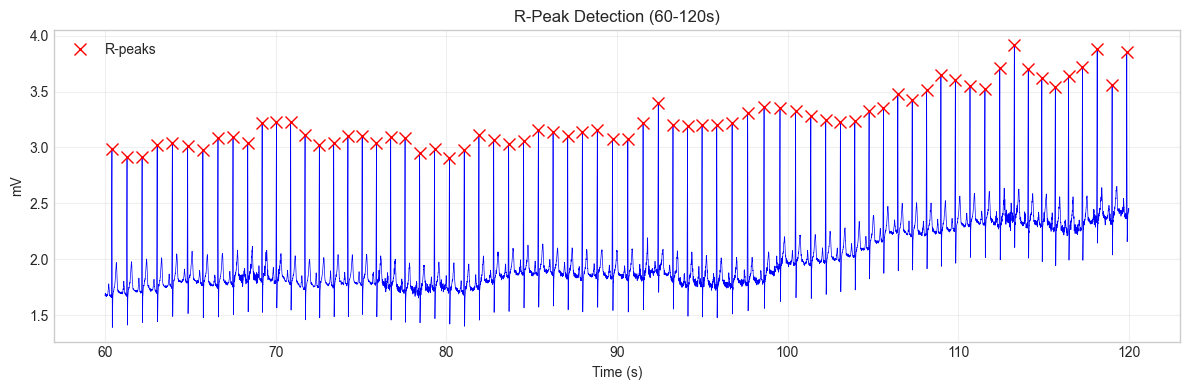

In [47]:
# Visualize the same 60s window as before
plot_r_peaks(ecg_filtered, r_peaks_indices, fs, start_sec=60, duration_sec=60)

## 5. Beat Validation

Following Burattini et al. (1999), we validate beats using two criteria:

### RR Stability
Reject segments where RR interval standard deviation > 10% of mean RR (filters arrhythmia/noise).

### Sinus Beat Verification
1. Compute a **median beat template** from all detected beats
2. Cross-correlate each beat with the template
3. Flag beats with correlation < 0.8 as non-sinus (ectopic or noisy)
4. Replace flagged beats with average of two preceding sinus beats

In [48]:
def analyze_rr_variability(r_peaks_indices, fs, window_size=128, threshold_percent=10.0):
    rr_variabilities = []
    valid_window_starts = []
    
    for i in range(0, len(r_peaks_indices), window_size):
        window_indices = r_peaks_indices[i:i + window_size]
        if len(window_indices) < window_size:
            continue
        
        rr_ints = np.diff(window_indices) / fs
        mean_rr = np.mean(rr_ints)
        variability = (np.std(rr_ints) / mean_rr) * 100 if mean_rr > 0 else 100.0 #if the ECG has RR standard deviation > 10% mean RR, the ECG is rejected
        rr_variabilities.append(variability)
        
        if variability <= threshold_percent:
            valid_window_starts.append(i)
    
    return np.array(rr_variabilities), valid_window_starts

In [49]:
def plot_rr_stats(rr_variabilities, threshold_percent=10.0):
    if len(rr_variabilities) == 0:
        print("No valid RR intervals found.")
        return
    
    rejected = np.sum(rr_variabilities > threshold_percent)
    print(f"Median RR Variability: {np.median(rr_variabilities):.1f}%")
    print(f"Windows rejected (>{threshold_percent}%): {rejected}/{len(rr_variabilities)}")
    
    plt.figure(figsize=(10, 4))
    plt.hist(rr_variabilities, bins=50, color='steelblue', edgecolor='white')
    plt.axvline(threshold_percent, color='red', ls='--', lw=2, label=f'Threshold ({threshold_percent}%)')
    plt.title("RR Variability Distribution")
    plt.xlabel("RR Std / Mean RR (%)")
    plt.ylabel("Count")
    plt.legend()
    plt.show()

Median RR Variability: 4.5%
Windows rejected (>10.0%): 64/945


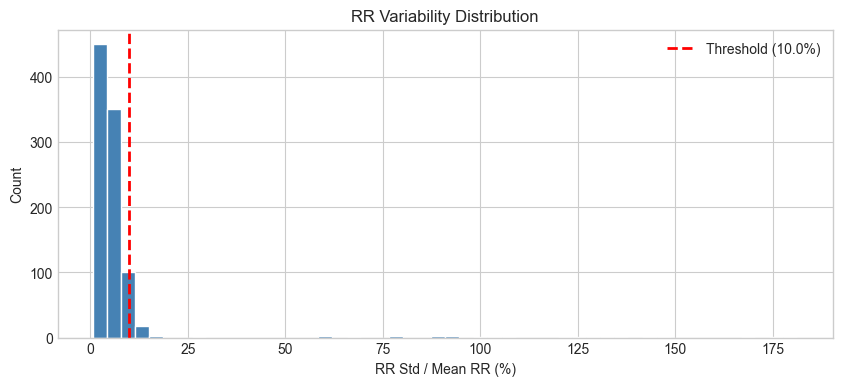

In [50]:
rr_stats, valid_starts = analyze_rr_variability(r_peaks_indices, fs)
plot_rr_stats(rr_stats)

In [51]:
def check_rr_stability(window_indices, fs, rr_tolerance=0.10):
    rr_ints = np.diff(window_indices) / fs
    rr_mean = np.mean(rr_ints)
    rr_std = np.std(rr_ints)
    return rr_std <= rr_tolerance * rr_mean

def extract_beats(ecg_filtered, window_indices, qrs_window_sec, fs):
    half_window = int(qrs_window_sec * fs)
    beats = []
    for idx in window_indices:
        start, end = idx - half_window, idx + half_window
        if start >= 0 and end < len(ecg_filtered):
            beats.append(ecg_filtered[start:end])
    return beats

def check_sinus_beats(beats, corr_threshold=0.8, max_non_sinus=10):
    if len(beats) < 2:
        return False
    median_template = np.median(beats, axis=0)
    non_sinus = sum(1 for beat in beats 
                    if np.std(beat) > 0 and np.corrcoef(beat, median_template)[0, 1] < corr_threshold)
    return non_sinus <= max_non_sinus

In [52]:
def validate_and_segment_windows(ecg_filtered, r_peaks_indices, fs, 
                                 window_size=128, rr_tolerance=0.10, 
                                 qrs_window_sec=0.15, corr_threshold=0.8, max_non_sinus=10):
    valid_windows = []
    stats = {'total': 0, 'rejected_rr': 0, 'rejected_sinus': 0}

    for i in range(0, len(r_peaks_indices), window_size):
        window_indices = r_peaks_indices[i:i + window_size]
        if len(window_indices) < window_size - 2:
            continue
        
        stats['total'] += 1
        
        if not check_rr_stability(window_indices, fs, rr_tolerance):
            stats['rejected_rr'] += 1
            continue
        
        beats = extract_beats(ecg_filtered, window_indices, qrs_window_sec, fs)
        if len(beats) < window_size - 2 or not check_sinus_beats(beats, corr_threshold, max_non_sinus):
            stats['rejected_sinus'] += 1
            continue
        
        valid_windows.append(window_indices)
    
    n, t = len(valid_windows), stats['total']
    print(f"Validation: {n}/{t} windows accepted ({n/t*100:.0f}%)" if t > 0 else "No windows")
    
    return valid_windows

In [53]:
valid_windows = validate_and_segment_windows(ecg_filtered, r_peaks_indices, fs)

Validation: 879/945 windows accepted (93%)


## 6. Baseline Removal

Following Burattini et al. (1999), we remove baseline wander using cubic spline interpolation.

### Method
1. Identify **PQ junction** for each beat (approximated as 50 ms before R-peak)
2. Fit a **3rd-order cubic spline** through these reference points
3. Subtract the spline from the signal

> **Why?** TWA involves microvolt-level changes. Even slight baseline drift can mask or mimic alternans.

In [54]:
def remove_baseline_spline(ecg_filtered, window_r_peaks, fs, pr_offset_sec=0.05):
    if len(window_r_peaks) < 4:
        return None
    
    start_idx = max(0, window_r_peaks[0] - int(fs))
    end_idx = min(len(ecg_filtered), window_r_peaks[-1] + int(fs))
    segment = ecg_filtered[start_idx:end_idx]
    
    # PQ junction points (fiducial)
    offset = int(pr_offset_sec * fs)
    fid_idx = [r - offset for r in window_r_peaks if start_idx <= r - offset < end_idx]
    fid_val = [ecg_filtered[i] for i in fid_idx]
    
    if len(fid_idx) < 4:
        return None
    
    # Fit spline and subtract
    local_x = np.array(fid_idx) - start_idx
    baseline = CubicSpline(local_x, fid_val)(np.arange(len(segment)))
    
    return {
        "ecg_clean": segment - baseline,
        "baseline": baseline,
        "segment_indices": np.arange(start_idx, end_idx),
        "fiducial_indices": np.array(fid_idx)
    }

In [55]:
def plot_baseline_removal(ecg_filtered, result_dict, fs, zoom_seconds=10):
    if result_dict is None:
        return
    
    idx = result_dict["segment_indices"]
    baseline = result_dict["baseline"]
    clean = result_dict["ecg_clean"]
    fid_idx = result_dict["fiducial_indices"]
    
    t = idx / fs
    original = ecg_filtered[idx[0]:idx[-1]+1]
    
    plt.figure(figsize=(12, 4))
    plt.plot(t, original, 'r-', alpha=0.4, lw=0.5, label='Original')
    plt.plot(t, baseline, 'k-', lw=1.5, label='Baseline')
    plt.plot(t, clean, 'b-', lw=0.5, label='Clean')
    plt.plot(fid_idx / fs, ecg_filtered[fid_idx], 'go', ms=4, label='Fiducial (PQ)')
    plt.title("Baseline Removal")
    plt.xlabel("Time (s)")
    plt.ylabel("mV")
    plt.xlim(t[0], t[0] + zoom_seconds)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

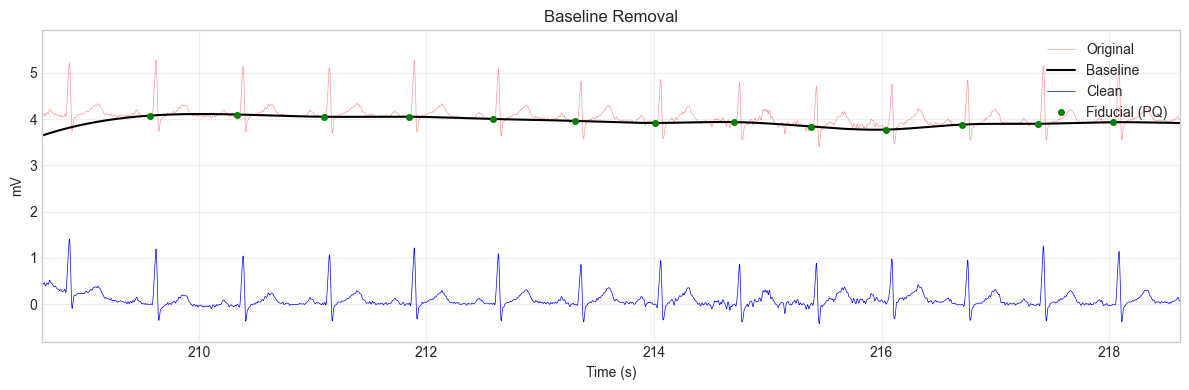

In [56]:
if len(valid_windows) > 0:
    win_r_peaks = valid_windows[0]
    baseline_res = remove_baseline_spline(ecg_filtered, win_r_peaks, fs)
    plot_baseline_removal(ecg_filtered, baseline_res, fs)
else:
    print("No valid windows - Analysis stopped")
    twa_results = {"magnitude": 0, "result_status": "INDETERMINATE - No valid windows"}
    clean_matrix = None

### Interpreting the Plot

- **Green dots:** PQ junction points (~50ms before R-peak) — the isoelectric reference

- **Black line:** Cubic spline fitted through fiducial points, modeling baseline drift

- **Blue line:** Corrected signal with all PQ junctions aligned to 0 mV

## 7. T-Wave Extraction

Isolate the T-wave for each beat using adaptive windowing based on heart rate.

### Window Parameters

| RR Interval | T-wave Onset (after R-peak) |
|-------------|---------------------------|
| < 0.6s | 60 ms |
| 0.6 – 1.1s | 100 ms |
| > 1.1s | 150 ms |

**Window duration:** 0.44 × √RR × 1000 ms

### Non-Sinus Beat Handling
Beats with low template correlation are not deleted. Instead, their T-wave is replaced with the average of the two preceding valid beats — preserving series continuity for spectral analysis.

In [57]:
def detect_non_sinus_beats(ecg_clean, local_r_peaks, fs, corr_threshold=0.8):
    half_win = int(0.06 * fs)
    beats, valid_idx = [], []
    
    for i, p in enumerate(local_r_peaks):
        if p - half_win >= 0 and p + half_win < len(ecg_clean):
            beats.append(ecg_clean[p - half_win:p + half_win])
            valid_idx.append(i)
    
    if not beats:
        return None
    
    median_beat = np.median(beats, axis=0)
    is_sinus = np.zeros(len(local_r_peaks), dtype=bool)
    
    for i, b in zip(valid_idx, beats):
        if np.std(b) > 0 and np.corrcoef(b, median_beat)[0, 1] > corr_threshold:
            is_sinus[i] = True

    return is_sinus

def get_twave_window(rr):
    offset_ms = 60 if rr < 0.6 else (100 if rr < 1.1 else 150)
    duration_ms = 0.44 * np.sqrt(rr) * 1000
    return offset_ms, duration_ms

In [58]:
def extract_t_waves(ecg_clean, local_r_peaks, fs, replace_non_sinus=True):
    is_sinus = detect_non_sinus_beats(ecg_clean, local_r_peaks, fs)

    if is_sinus is None or (len(is_sinus) - np.sum(is_sinus)) > 10:
        return None, None, None
    
    rr_intervals = np.diff(local_r_peaks) / fs
    if len(rr_intervals) == 0:
        return None, None, None
    
    # Fixed length based on median RR
    median_rr = np.median(rr_intervals)
    fixed_len = int(0.44 * np.sqrt(median_rr) * fs)
    
    extracted_t, t_onsets, beat_map = [], [], []
    
    for i, r_idx in enumerate(local_r_peaks):
        rr = rr_intervals[i] if i < len(rr_intervals) else rr_intervals[-1]
        offset_ms, dur_ms = get_twave_window(rr)
        
        onset = r_idx + int(offset_ms / 1000 * fs)
        dur_samples = int(dur_ms / 1000 * fs)
        
        if onset + dur_samples > len(ecg_clean) or dur_samples < 2:
            continue
        
        t_raw = ecg_clean[onset:onset + dur_samples]
        x_old = np.linspace(0, 1, len(t_raw))
        x_new = np.linspace(0, 1, fixed_len)
        extracted_t.append(CubicSpline(x_old, t_raw)(x_new))
        t_onsets.append(onset)
        beat_map.append(i)
    
    # Replace non-sinus beats
    if replace_non_sinus:
        for ext_i, orig_i in enumerate(beat_map):
            if not is_sinus[orig_i]:
                prev = [j for j in range(ext_i) if is_sinus[beat_map[j]]][-2:]
                if len(prev) >= 2:  # Require exactly 2
                    extracted_t[ext_i] = np.mean([extracted_t[p] for p in prev], axis=0)
                elif len(prev) == 1:
                    extracted_t[ext_i] = extracted_t[prev[0]]  # Use the 1 available
                # If no preceding sinus beats, this T-wave should probably be excluded
    
    return extracted_t, t_onsets, is_sinus

In [59]:
def plot_t_waves(extracted_t_waves, num_to_plot=10):
    if not extracted_t_waves:
        return
    
    count = min(num_to_plot, len(extracted_t_waves))
    plt.figure(figsize=(10, 4))
    for j in range(count):
        plt.plot(extracted_t_waves[j], alpha=0.6)
    plt.title(f"Extracted T-Waves (first {count} beats)")
    plt.xlabel("Samples")
    plt.ylabel("mV")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

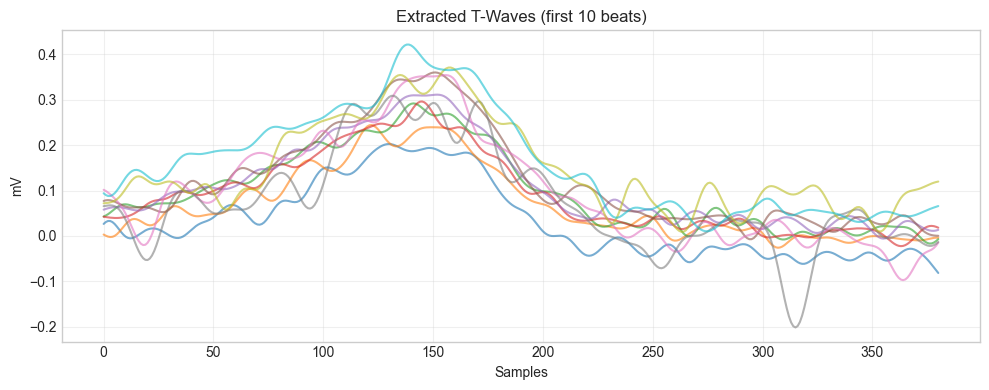

In [60]:
t_waves = None

if len(valid_windows) > 0:
    target_window = valid_windows[0]
    baseline_res = remove_baseline_spline(ecg_filtered, target_window, fs)
    
    if baseline_res:
        ecg_clean = baseline_res["ecg_clean"]
        start_idx = baseline_res["segment_indices"][0]
        local_r_peaks = target_window - start_idx
        
        t_waves, onsets, sinus_status = extract_t_waves(ecg_clean, local_r_peaks, fs)
        plot_t_waves(t_waves)
else:
    print("No valid windows")

## 8. T-Wave Synchronization

Align all T-waves to a common reference to eliminate temporal jitter that could mimic alternans.

### Method
1. Compute **median T-wave** as reference template
2. For each beat, shift T-wave within ±30 ms range
3. Select shift that maximizes cross-correlation with template

In [61]:
def synchronize_t_waves(extracted_t_waves, max_shift_ms=30, fs=1000):
    
    if not extracted_t_waves:
        return [], []
    
    n_beats = len(extracted_t_waves)
    min_len = min(len(t) for t in extracted_t_waves)
    max_shift = int(max_shift_ms / 1000 * fs)
    safe_len = min_len - 2 * max_shift
    
    if safe_len <= 0:
        return [t[:min_len] for t in extracted_t_waves], [0] * n_beats

    center = max_shift
    central_segs = [t[center:center + safe_len] for t in extracted_t_waves]
    ref_template = np.median(central_segs, axis=0)
    
    aligned, shifts = [], []
    
    for t_wave in extracted_t_waves:
        best_corr, best_shift, best_seg = -1.0, 0, t_wave[center:center + safe_len]
        
        for s in range(-max_shift, max_shift + 1):
            start = center + s
            if start < 0 or start + safe_len > len(t_wave):
                continue
            candidate = t_wave[start:start + safe_len]
            corr = np.corrcoef(candidate, ref_template)[0, 1] if np.std(candidate) > 0 else 0
            if corr > best_corr:
                best_corr, best_shift, best_seg = corr, s, candidate
        
        aligned.append(best_seg)
        shifts.append(best_shift)

    return aligned, shifts

In [62]:
def plot_synchronization(extracted_t, aligned_t, num_to_plot=20):
    if not extracted_t or not aligned_t:
        return
    
    limit = min(num_to_plot, len(extracted_t))
    min_len = len(aligned_t[0])
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    
    for i in range(limit):
        center = len(extracted_t[i]) // 2
        half = min_len // 2
        seg = extracted_t[i][center-half:center+half] if center > half else extracted_t[i][:min_len]
        axes[0].plot(seg, alpha=0.5)
        axes[1].plot(aligned_t[i], alpha=0.5)
    
    axes[0].set(title="Before Synchronization", ylabel="mV")
    axes[1].set(title="After Synchronization", ylabel="mV")
    for ax in axes:
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

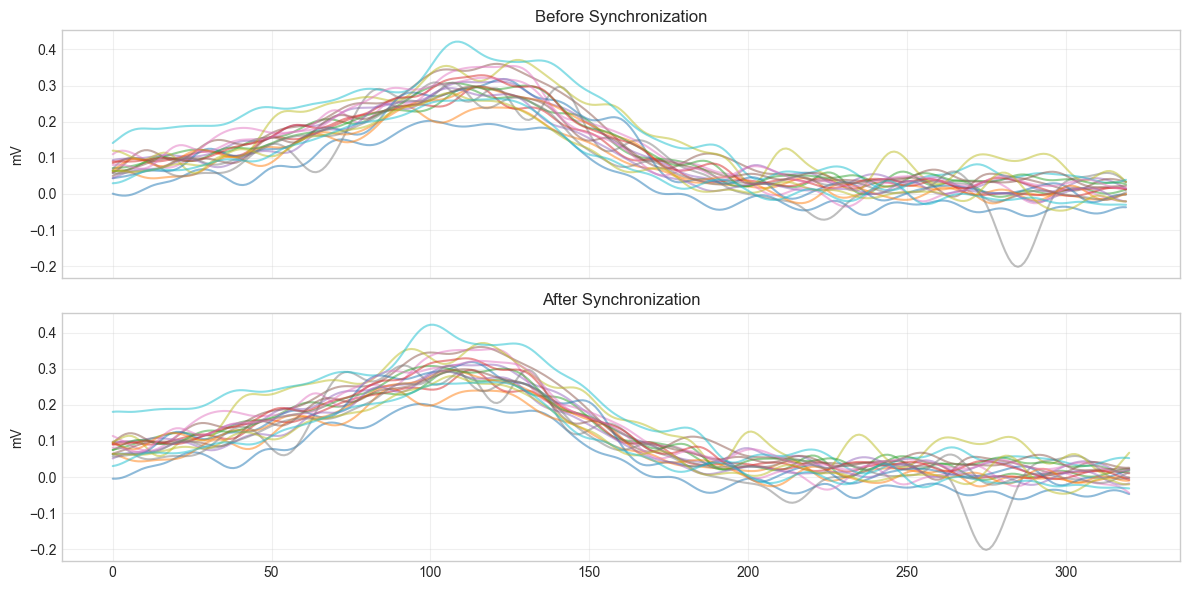

In [63]:
aligned_t_waves = None
if t_waves:
    aligned_t_waves, shift_vals = synchronize_t_waves(t_waves)
    plot_synchronization(t_waves, aligned_t_waves)

## 9. Respiratory Modulation Removal

Respiration causes slow T-wave amplitude variations (0.2–0.3 Hz) that can interfere with TWA detection.

### Method
1. Arrange T-waves as matrix (128 beats × N samples)
2. Apply **band-stop filter** (0.14–0.35 cycles/beat) along beat axis
3. TWA at 0.5 cycles/beat passes through unaffected

In [64]:
def remove_respiratory_modulation(aligned_t_waves, low_cut=0.14, high_cut=0.35, order=4):
    if not aligned_t_waves:
        return None, None
    
    min_len = min(len(t) for t in aligned_t_waves)
    t_matrix = np.array([t[:min_len] for t in aligned_t_waves])
    
    # Band-stop filter (frequencies normalized to Nyquist = 0.5 cycles/beat)
    b, a = signal.butter(order, [low_cut * 2, high_cut * 2], btype='bandstop')
    t_matrix_clean = signal.filtfilt(b, a, t_matrix, axis=0)
    
    return t_matrix_clean, t_matrix

In [65]:
def plot_respiratory_removal(t_orig, t_clean):
    if t_orig is None or t_clean is None:
        return
    
    peak_idx = np.argmax(np.mean(t_orig, axis=0))
    
    plt.figure(figsize=(12, 4))
    plt.plot(t_orig[:, peak_idx], 'r-', alpha=0.5, lw=0.8, label='Before')
    plt.plot(t_clean[:, peak_idx], 'b-', lw=0.8, label='After')
    plt.title("Respiratory Modulation Removal")
    plt.xlabel("Beat Number")
    plt.ylabel("mV")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

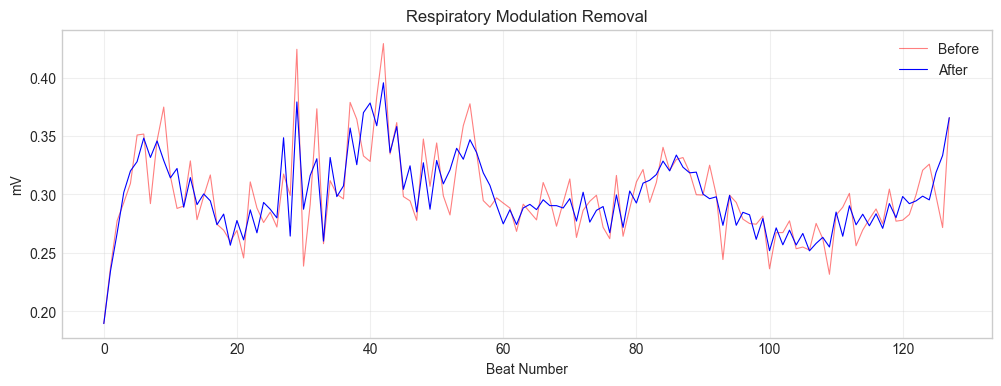

In [66]:
if aligned_t_waves:
    clean_matrix, original_matrix = remove_respiratory_modulation(aligned_t_waves)
    plot_respiratory_removal(original_matrix, clean_matrix)

## 10. TWA Detection (Correlation Method)

Implementation of the Correlation Method from Burattini et al. (1999), Equations 1–5.

### Alternans Correlation Index (ACI)
For each T-wave $T_j$, compute its scaling factor relative to the median template $T_{mdn}$:

$$ACI_j = \frac{\sum_i T_j(i) \cdot T_{mdn}(i)}{\sum_i T_{mdn}^2(i)}$$

### TWA Amplitude per Beat
The alternans amplitude (μV) is derived from how much $ACI_j$ deviates from 1:

$$A_{CM}(j) = 2 \cdot |ACI_j - 1| \cdot \frac{\sum_i T_{mdn}^2(i)}{\sum_i |T_{mdn}(i)|}$$

### Detection Criteria
- **Alternans pattern:** Runs of ≥7 beats where ACI alternates direction

- **Global magnitude:** $MAG_{CM} = \text{Mean}(A_{CM}) \times \text{Duration}$

- **Threshold:** $MAG_{CM} > 550\ \mu V$ indicates clinically significant TWA

In [67]:
def compute_aci(t_wave_matrix, t_mdn):
    """Alternans Correlation Index (Eq. 1)"""
    sum_t_mdn_sq = np.sum(t_mdn**2)
    if sum_t_mdn_sq == 0:
        return None
    return np.sum(t_wave_matrix * t_mdn, axis=1) / sum_t_mdn_sq

def compute_acm(aci_values, t_mdn):
    """TWA amplitude per beat in μV (Eq. 2)"""
    sum_t_mdn_sq = np.sum(t_mdn**2)
    sum_abs_t_mdn = np.sum(np.abs(t_mdn))
    norm_factor = (sum_t_mdn_sq / sum_abs_t_mdn) * 1000  # mV -> μV
    return 2 * np.abs(aci_values - 1) * norm_factor

def find_alternating_beats(aci_values, min_run=7):
    """Find beats with sustained alternans (≥7 consecutive flips)"""
    signs = np.sign(np.diff(aci_values))
    is_alt = np.zeros(len(aci_values), dtype=bool)
    
    for i in range(len(signs) - (min_run - 2)):
        seg = signs[i:i + min_run - 1]
        if np.all(seg[:-1] * seg[1:] < 0):
            is_alt[i:i + min_run] = True
    
    return is_alt

In [68]:
def detect_twa_correlation_method(t_wave_matrix, threshold=550.0):
    if t_wave_matrix is None or len(t_wave_matrix) == 0:
        return None
    
    if isinstance(t_wave_matrix, list):
        min_len = min(len(t) for t in t_wave_matrix)
        t_wave_matrix = np.array([t[:min_len] for t in t_wave_matrix])
    
    t_mdn = np.median(t_wave_matrix, axis=0)
    
    aci = compute_aci(t_wave_matrix, t_mdn)
    if aci is None:
        return None
    
    acm = compute_acm(aci, t_mdn)
    is_alt = find_alternating_beats(aci)
    
    # Zero out non-alternating beats
    final_acm = acm.copy()
    final_acm[~is_alt] = 0.0
    
    n_alt = np.sum(is_alt)
    mean_amp = np.mean(final_acm[is_alt]) if n_alt > 0 else 0.0
    magnitude = mean_amp * n_alt
    status = "POSITIVE" if magnitude > threshold else "NEGATIVE"
    
    #print(f"TWA: {magnitude:.0f} μV ({n_alt} alternating beats, {mean_amp:.1f} μV mean) → {status}")
    
    return {
        "aci_values": aci,
        "acm_values": acm,
        "is_alternating": is_alt,
        "magnitude": magnitude,
        "result_status": status
    }

In [69]:
def plot_twa_results(results):
    if not results:
        print("No results to plot.")
        return
    
    aci = results["aci_values"]
    acm = results["acm_values"]
    mask = results["is_alternating"]
    
    fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
    
    axes[0].plot(aci, 'b-', lw=0.8)
    axes[0].axhline(1.0, color='k', ls='--', alpha=0.5)
    axes[0].set(ylabel='ACI', title='Alternans Correlation Index')
    
    axes[1].bar(range(len(acm)), acm, color=['green' if m else 'lightgray' for m in mask], width=1)
    axes[1].set(ylabel='μV', title='TWA Amplitude')
    
    axes[2].fill_between(range(len(mask)), mask, step='mid', alpha=0.5)
    axes[2].set(xlabel='Beat Number', ylabel='', title='Alternating Beats', ylim=(-0.1, 1.1))
    
    for ax in axes:
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

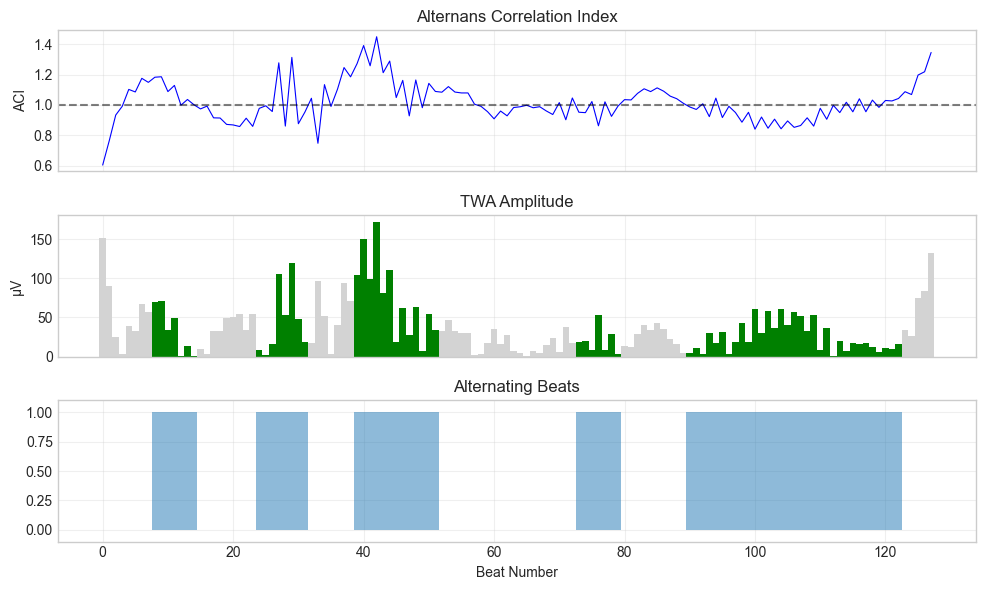

In [70]:
if 'clean_matrix' in locals() and clean_matrix is not None:
    twa_results = detect_twa_correlation_method(clean_matrix)
    plot_twa_results(twa_results)

## 11. Full Record Analysis

Automate the pipeline across all valid 128-beat windows in the recording.

### Process
1. Iterate through all `valid_windows` from Step 5
2. Apply Steps 6–10 (baseline removal → TWA detection) to each window
3. Collect TWA magnitude for each window

### Clinical Metrics
- **TWA Positive:** Window with magnitude > 550 μV
- **TWA Burden:** Percentage of windows that are TWA-positive

> **Note:** The implementation includes quality filters not in the original Burattini method to reduce false positives in ambulatory data.

In [71]:
def analyze_twa_final(window_indices, fs, ecg_filtered):
    fail = {"magnitude": 0, "amp": 0, "n_alt": 0, "valid": False, "reason": ""}

    res = remove_baseline_spline(ecg_filtered, window_indices, fs)
    if res is None:
        return {**fail, "reason": "Baseline failure"}
    
    ecg_clean = res["ecg_clean"]
    local_r_peaks = window_indices - res["segment_indices"][0]
    
    extracted_t, _, _ = extract_t_waves(ecg_clean, local_r_peaks, fs)
    if extracted_t is None:
        return {**fail, "reason": "Too many non-sinus beats"}
    
    aligned_t, _ = synchronize_t_waves(extracted_t)
    
    ref_t = np.median(aligned_t, axis=0)
    strength = (np.max(ref_t) - np.min(ref_t)) * 1000
    if strength < 10:
        return {**fail, "reason": "Low signal"}
    
    t_clean, _ = remove_respiratory_modulation(aligned_t)
    if t_clean is None:
        return {**fail, "reason": "Filter failed"}
    
    twa = detect_twa_correlation_method(t_clean)
    if twa is None:
        return {**fail, "reason": "Detection failed"}
    
    return {
        "magnitude": twa["magnitude"],
        "amp": np.mean(twa["acm_values"][twa["is_alternating"]]) if np.any(twa["is_alternating"]) else 0,
        "n_alt": np.sum(twa["is_alternating"]),
        "valid": True,
        "reason": "Success"
    }

In [72]:
twa_magnitudes = []
full_results = []

for i, win in enumerate(valid_windows):
    res = analyze_twa_final(win, fs, ecg_filtered)
    
    if res["valid"]:
        twa_magnitudes.append(res["magnitude"])
        start_sec = win[0] / fs
        full_results.append({
            "Window": i,
            "Beats": res["n_alt"],
            "Amp (μV)": round(res["amp"], 1),
            "Mag (μV)": round(res["magnitude"], 0),
            "Time": f"{int(start_sec//3600):02d}:{int((start_sec%3600)//60):02d}"
        })
    else:
        twa_magnitudes.append(0)

twa_magnitudes = np.array(twa_magnitudes)
positive_count = np.sum(twa_magnitudes > 550)
burden = positive_count / len(valid_windows) * 100 if len(valid_windows) > 0 else 0

#print(f"TWA Burden: {positive_count}/{len(valid_windows)} windows ({burden:.1f}%)")
#print(f"Diagnosis: {'POSITIVE' if burden > 50 else 'NEGATIVE'}")

if full_results:
    df = pd.DataFrame(full_results).sort_values("Mag (μV)", ascending=False)
    display(df.head(10))

,Window,Beats,Amp (μV),Mag (μV),Time
206,206,120,238.9,28666.0,05:29
207,207,127,200.5,25462.0,05:30
265,265,121,207.4,25092.0,06:33
264,264,127,191.6,24332.0,06:32
208,208,124,189.5,23498.0,05:31
215,215,121,189.1,22879.0,05:39
212,212,125,181.8,22729.0,05:36
210,210,124,180.8,22413.0,05:34
211,211,108,206.7,22319.0,05:35
224,224,126,175.4,22103.0,05:50


## 12. Multi-Patient Analysis

Analyze TWA across all SCD patients in the dataset using the validated pipeline.

### Methodology

1. **Best Window Selection:** For each patient, identify the cleanest 128-beat window based on morphological consistency (highest mean correlation with template)

2. **Single-Window Analysis:** Apply Steps 6–10 to the selected window

3. **Classification:** TWA Positive if magnitude > 550 μV

---

**Burattini et al. (1999):** *"randomly selected one 128-beat ECG segment characterized by good quality"* — manual selection.

**Our approach:** `select_cleanest_window()` automates this by choosing the window with highest T-wave morphological consistency.

**Result:** Same goal — analyze only the clearest, artifact-free segments.


In [73]:
def select_cleanest_window(valid_windows, ecg_filtered, fs):
    best_window, best_score = None, -1.0
    
    for indices in valid_windows:
        res = remove_baseline_spline(ecg_filtered, indices, fs)
        if not res:
            continue
        
        local_r = indices - res["segment_indices"][0]
        t_waves, _, _ = extract_t_waves(res["ecg_clean"], local_r, fs)
        
        if t_waves is None or len(t_waves) < 10:
            continue
        
        t_matrix = np.array(t_waves)
        median_t = np.median(t_matrix, axis=0)
        
        if np.ptp(median_t) < 0.01:
            continue
        
        corrs = [np.corrcoef(t, median_t)[0, 1] for t in t_matrix if np.std(t) > 0]
        score = np.mean(corrs) if corrs else 0
        
        if score > best_score:
            best_score, best_window = score, indices
    
    return best_window

In [74]:
def analyze_all_leads(record_path):
    try:
        record = wfdb.rdrecord(record_path)
    except:
        return None, None, None
    
    fs = record.fs
    max_mag, best_lead, best_res = 0, None, None
    
    for lead_idx, lead_name in enumerate(record.sig_name):
        try:
            ecg = record.p_signal[:, lead_idx]
            ecg_filt = apply_lowpass_filter(ecg, fs)
            r_peaks = detect_r_peaks(ecg_filt, fs)
            valid_wins = validate_and_segment_windows(ecg_filt, r_peaks, fs)
            
            if not valid_wins:
                continue
            
            best_win = select_cleanest_window(valid_wins, ecg_filt, fs)
            if best_win is None:
                continue
            
            res = analyze_twa_final(best_win, fs, ecg_filt)
            
            if res and res.get("valid") and res["magnitude"] > max_mag:
                max_mag = res["magnitude"]
                best_lead = lead_name
                best_res = res
        except:
            continue
    
    return max_mag, best_lead, best_res

In [75]:
def run_scd_analysis(data_folder="data"):
    files = sorted(set(os.path.splitext(p)[0] for p in glob.glob(f"{data_folder}/P00*.dat")))
    
    print(f"Analyzing {len(files)} SCD patients\n")
    
    results = []
    for path in files:
        pid = os.path.basename(path)
        mag, lead, res = analyze_all_leads(path)
        
        if res and mag > 0:
            status = "POS" if mag > 550 else "NEG"
            print(f"  {status} {pid} (Lead {lead}): {mag:.0f} μV")
            results.append({
                "Patient": pid,
                "Lead": lead,
                "Magnitude": mag,
                "Amplitude": res["amp"],
                "Beats": res["n_alt"],
                "Positive": mag > 550
            })
        else:
            print(f"  --- {pid}: No valid analysis")
    
    return pd.DataFrame(results)

In [76]:
def plot_scd_results(df):
    if df.empty:
        print("No results to plot")
        return
    
    #print(f"\nSCD Group: {len(df)} patients")
    #print(f"Mean: {df['Magnitude'].mean():.0f} μV, Max: {df['Magnitude'].max():.0f} μV")
    #print(f"Positive: {df['Positive'].sum()}/{len(df)} ({df['Positive'].mean()*100:.0f}%)")
    
    plt.figure(figsize=(6, 5))
    plt.boxplot(df['Magnitude'])
    plt.scatter(np.ones(len(df)) + np.random.normal(0, 0.03, len(df)), df['Magnitude'], alpha=0.5)
    plt.axhline(550, color='red', ls='--', label='Threshold')
    plt.title('TWA Magnitude (SCD Patients)')
    plt.ylabel('μV')
    plt.legend()
    plt.tight_layout()
    plt.show()

Analyzing 8 SCD patients

Validation: 0/1155 windows accepted (0%)
Validation: 0/1157 windows accepted (0%)
Validation: 0/1155 windows accepted (0%)
  --- P0001: No valid analysis
Validation: 882/945 windows accepted (93%)
Validation: 837/938 windows accepted (89%)
Validation: 329/839 windows accepted (39%)
  POS P0002 (Lead Z): 2034 μV
Validation: 0/934 windows accepted (0%)
Validation: 0/908 windows accepted (0%)
Validation: 0/927 windows accepted (0%)
  --- P0003: No valid analysis
Validation: 157/723 windows accepted (22%)
Validation: 526/724 windows accepted (73%)
Validation: 493/728 windows accepted (68%)
  POS P0004 (Lead X): 2354 μV
Validation: 71/727 windows accepted (10%)
Validation: 173/761 windows accepted (23%)
Validation: 352/763 windows accepted (46%)
  POS P0005 (Lead Y): 2982 μV
Validation: 336/584 windows accepted (58%)
Validation: 418/603 windows accepted (69%)
Validation: 591/644 windows accepted (92%)
  POS P0006 (Lead X): 1092 μV
Validation: 806/882 windows accept

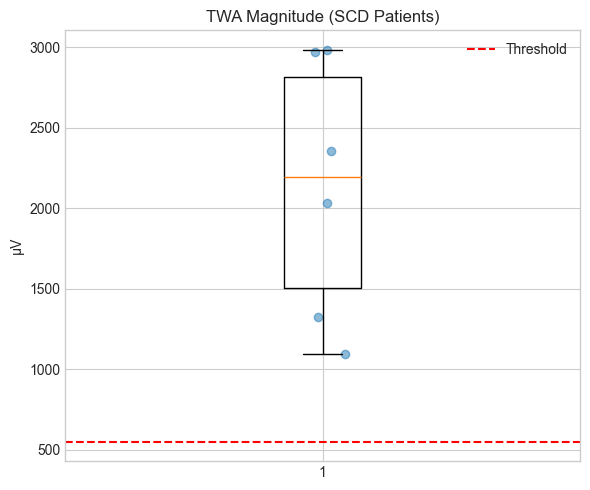

In [77]:
results_scd = run_scd_analysis()
plot_scd_results(results_scd)